Data Collection and loading datset

In [13]:
# ==========================================
# CUSTOMER SEGMENTATION PROJECT
# KMEANS vs DBSCAN WITH INTERPRETATION
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score


# ------------------------------------------
# 1 Load Dataset
# ------------------------------------------
data = pd.read_csv("Mall_Customers.csv")

print("\nFirst 5 rows of dataset\n")
print(data.head())









First 5 rows of dataset

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


Exploaratory data analysis

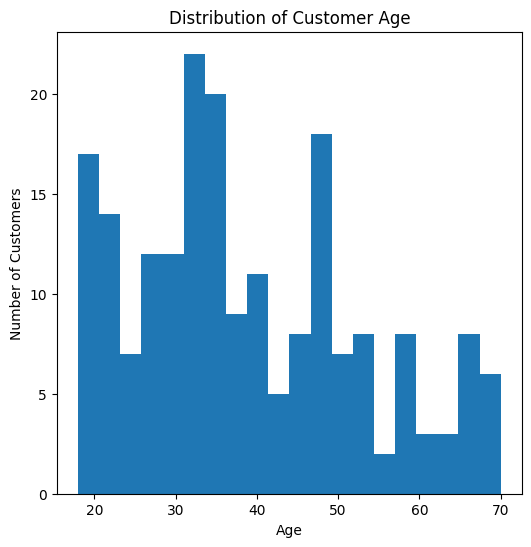

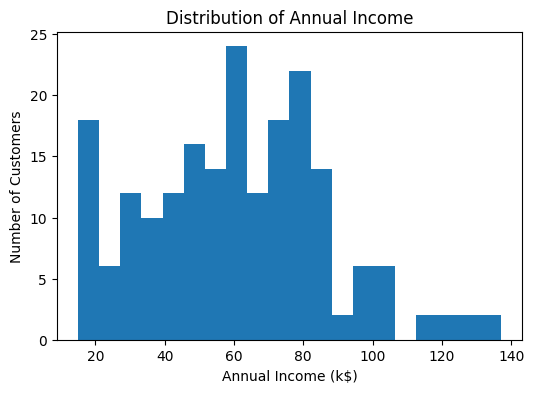

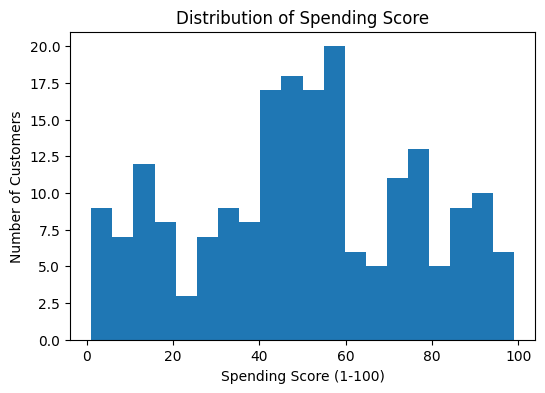

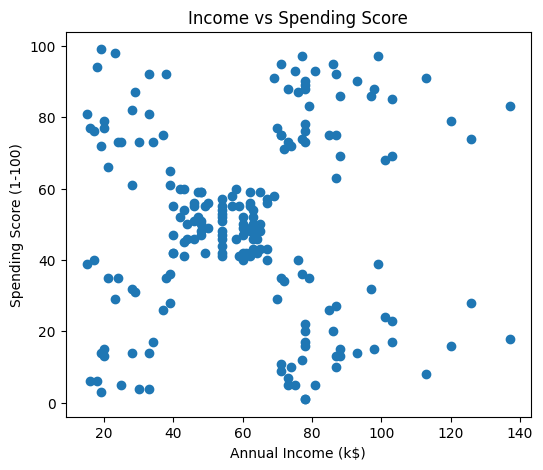

In [14]:
#Distribution of age
plt.figure(figsize=(6,6))
plt.hist(data['Age'], bins=20)
plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

#Annual Income distribution
plt.figure(figsize=(6,4))
plt.hist(data['Annual Income (k$)'], bins=20)
plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")
plt.show()

#Spending score distribution
plt.figure(figsize=(6,4))
plt.hist(data['Spending Score (1-100)'], bins=20)
plt.title("Distribution of Spending Score")
plt.xlabel("Spending Score (1-100)")
plt.ylabel("Number of Customers")
plt.show()

#Income vs spending scatter plot
plt.figure(figsize=(6,5))

plt.scatter(
    data['Annual Income (k$)'],
    data['Spending Score (1-100)']
)

plt.title("Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.show()

Selecting feature and Feature scaling

In [15]:
# ------------------------------------------
# 2 Select Features
# ------------------------------------------
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]


# ------------------------------------------
# 3 Feature Scaling
# ------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



Clustering algorithm

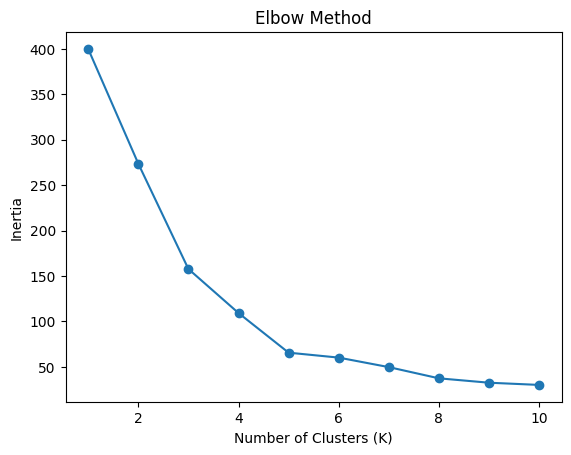

In [16]:

# ------------------------------------------
# 4 Elbow Method to find optimal K
# ------------------------------------------
inertia = []
K_range = range(1,11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()


# ------------------------------------------
# 5 Apply KMeans
# ------------------------------------------
kmeans = KMeans(n_clusters=5, random_state=42)

kmeans_labels = kmeans.fit_predict(X_scaled)

data["KMeans_cluster"] = kmeans_labels

# ------------------------------------------
# 6 Apply DBSCAN
# ------------------------------------------
dbscan = DBSCAN(eps=0.5, min_samples=5)

dbscan_labels = dbscan.fit_predict(X_scaled)

data["DBSCAN_cluster"] = dbscan_labels




Silhouette Score comparison

In [17]:
# ------------------------------------------
# 7 Silhouette Score
# ------------------------------------------
kmeans_score = silhouette_score(X_scaled, kmeans_labels)

# remove outliers for dbscan score
dbscan_score = silhouette_score(
    X_scaled[dbscan_labels != -1],
    dbscan_labels[dbscan_labels != -1]
)

print("\nSilhouette Score")
print("KMeans:", kmeans_score)
print("DBSCAN:", dbscan_score)


# ------------------------------------------
# 8 Print Best Algorithm
# ------------------------------------------
if kmeans_score > dbscan_score:
    print("\nKMEANS PERFORMS BETTER FOR THIS DATASET")
else:
    print("\nDBSCAN PERFORMS BETTER FOR THIS DATASET")
    




Silhouette Score
KMeans: 0.5546571631111091
DBSCAN: 0.3875583892728279

KMEANS PERFORMS BETTER FOR THIS DATASET


Visualisation and interpretation of K-Mean algorithm

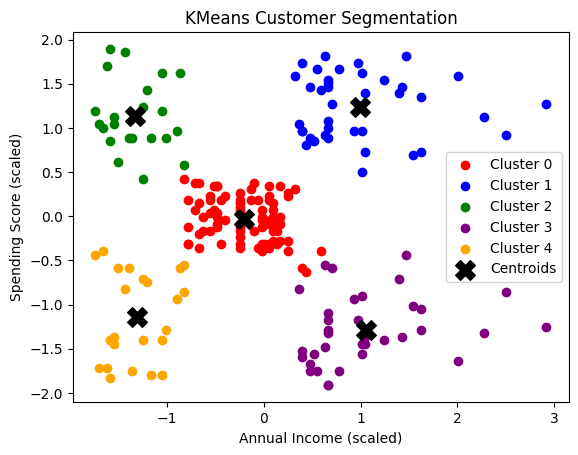


KMeans Color Legend
Cluster 0 = red
Cluster 1 = blue
Cluster 2 = green
Cluster 3 = purple
Cluster 4 = orange
Centroids = black X

KMEANS CLUSTER INTERPRETATION
                Annual Income (k$)  Spending Score (1-100)
KMeans_cluster                                            
0                        55.296296               49.518519
1                        86.538462               82.128205
2                        25.727273               79.363636
3                        88.200000               17.114286
4                        26.304348               20.913043
Cluster 0 → Average Customers
Cluster 1 → High Income High Spending (Premium Customers)
Cluster 2 → Low Income High Spending
Cluster 3 → High Income Low Spending (Target Customers)
Cluster 4 → Low Income Low Spending
---------------------------------------------------------------------------------------


In [18]:
# ------------------------------------------
# 9 KMEANS VISUALIZATION
# ------------------------------------------

colors = ['red','blue','green','purple','orange']

plt.figure()

for i in range(5):

    points = X_scaled[kmeans_labels == i]

    plt.scatter(
        points[:,0],
        points[:,1],
        color = colors[i],
        label = f"Cluster {i}"
    )

centroids = kmeans.cluster_centers_

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    marker='X',
    s=200,
    color='black',
    label="Centroids"
)

plt.title("KMeans Customer Segmentation")

plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")

plt.legend()

plt.show()


print("\nKMeans Color Legend")
print("Cluster 0 = red")
print("Cluster 1 = blue")
print("Cluster 2 = green")
print("Cluster 3 = purple")
print("Cluster 4 = orange")
print("Centroids = black X")

# ------------------------------------------
# 11 KMEANS CLUSTER INTERPRETATION
# ------------------------------------------

print("\nKMEANS CLUSTER INTERPRETATION")

summary = data.groupby("KMeans_cluster")[[
    'Annual Income (k$)',
    'Spending Score (1-100)'
]].mean()

print(summary)


for cluster in summary.index:

    income = summary.loc[cluster,'Annual Income (k$)']
    spending = summary.loc[cluster,'Spending Score (1-100)']

    if income > 70 and spending > 70:
        label = "High Income High Spending (Premium Customers)"

    elif income > 70 and spending < 40:
        label = "High Income Low Spending (Target Customers)"

    elif income < 40 and spending > 60:
        label = "Low Income High Spending"

    elif income < 40 and spending < 40:
        label = "Low Income Low Spending"

    else:
        label = "Average Customers"

    print("Cluster",cluster,"→",label)
    
    
print("---------------------------------------------------------------------------------------")



Visualisation and interpretation of DBSCAN algorithm

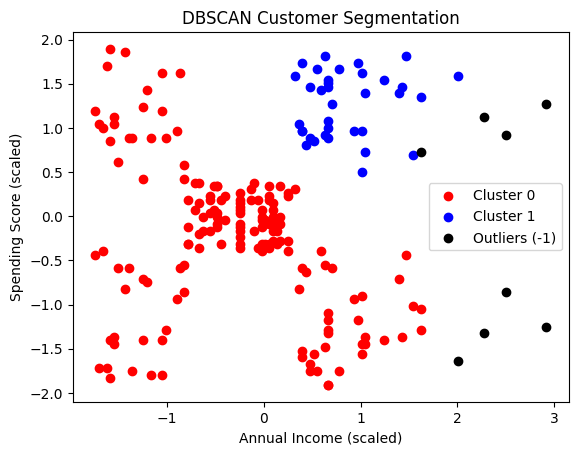


DBSCAN Color Legend
Clusters = colored groups
Outliers = black
------------------------------------------------------------------------------------------

DBSCAN CLUSTER INTERPRETATION
                Annual Income (k$)  Spending Score (1-100)
DBSCAN_cluster                                            
-1                      122.750000               46.875000
 0                       52.490446               43.101911
 1                       82.542857               82.800000

Note: Cluster -1 represents OUTLIERS detected by DBSCAN.


In [19]:


# ------------------------------------------
# 10 DBSCAN VISUALIZATION
# ------------------------------------------

unique_labels = set(dbscan_labels)

plt.figure()

for label in unique_labels:

    if label == -1:
        color = 'black'
        label_name = "Outliers (-1)"

    else:
        color = colors[label % len(colors)]
        label_name = f"Cluster {label}"

    points = X_scaled[dbscan_labels == label]

    plt.scatter(
        points[:,0],
        points[:,1],
        color=color,
        label=label_name
    )

plt.title("DBSCAN Customer Segmentation")

plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")

plt.legend()

plt.show()

print("\nDBSCAN Color Legend")
print("Clusters = colored groups")
print("Outliers = black")
print("------------------------------------------------------------------------------------------")



# ------------------------------------------
# 12 DBSCAN CLUSTER INTERPRETATION
# ------------------------------------------

print("\nDBSCAN CLUSTER INTERPRETATION")

summary_db = data.groupby("DBSCAN_cluster")[[
    'Annual Income (k$)',
    'Spending Score (1-100)'
]].mean()

print(summary_db)


print("\nNote: Cluster -1 represents OUTLIERS detected by DBSCAN.")